In [2]:
"""
07_final_model_selection_and_test_evaluation.ipynb

Purpose:
Train the final selected model on the combined train + validation data,
then evaluate it once on the untouched final test set.

Final selected pipeline:
- Model: LightGBM
- Tuning: best parameters from Notebook 05
- Imbalance handling: none

Selection rationale:
The tuned LightGBM model without resampling achieved the best validation
Macro F1 score among all tested configurations.

What this notebook does:
1. Load train / validation / test splits
2. Combine train + validation into one final training set
3. Train final LightGBM model with selected hyperparameters
4. Evaluate once on untouched test set
5. Save only the important final outputs
"""

# 1. Imports

# sys is used only to print Python version
import sys

# Path helps create clean file paths
from pathlib import Path

# warnings are hidden to keep notebook output cleaner
import warnings

# json is used to save final model parameters and selected feature names
import json

# joblib is used to save the final trained model
import joblib

# numpy and pandas are used for data handling
import numpy as np
import pandas as pd

# Metrics used for final test evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)

# Used for multiclass ROC-AUC
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")

# display() looks nicer in notebooks, but print() is used if unavailable
try:
    from IPython.display import display
except Exception:
    display = None

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Python :", sys.version.split()[0])
print("Pandas :", pd.__version__)
print("NumPy  :", np.__version__)


# 2. Model Import

# This notebook requires LightGBM because it is the final selected model
try:
    from lightgbm import LGBMClassifier
except Exception as exc:
    raise ImportError("LightGBM is required for this notebook.") from exc


# 3. Paths

PROJECT_ROOT = Path.cwd().parent
SPLITS_PATH = PROJECT_ROOT / "data" / "splits"
REPORTS_PATH = PROJECT_ROOT / "reports" / "final_test_evaluation"
MODELS_PATH = PROJECT_ROOT / "artifacts" / "final_model"
PREDS_PATH = PROJECT_ROOT / "artifacts" / "final_predictions"

REPORTS_PATH.mkdir(parents=True, exist_ok=True)
MODELS_PATH.mkdir(parents=True, exist_ok=True)
PREDS_PATH.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("SPLITS_PATH  :", SPLITS_PATH)
print("REPORTS_PATH :", REPORTS_PATH)
print("MODELS_PATH  :", MODELS_PATH)
print("PREDS_PATH   :", PREDS_PATH)


# 4. Helper Functions

def show_df(df: pd.DataFrame, n: int = 5) -> None:
    """
    Show the first few rows of a dataframe.
    """
    if display is not None:
        display(df.head(n))
    else:
        print(df.head(n))


def save_csv(df: pd.DataFrame, path: Path, index: bool = False) -> None:
    """
    Save dataframe as CSV.
    """
    df.to_csv(path, index=index)


def evaluate_multiclass(y_true, y_pred, y_proba, class_labels):
    """
    Compute the main final multi-class evaluation metrics.

    Macro F1 is the main metric because the classes are imbalanced
    and we want balanced performance across all classes.
    """
    result = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    # Convert multiclass labels into binary form for ROC-AUC
    y_true_bin = label_binarize(y_true, classes=class_labels)

    result["roc_auc_ovr_macro"] = roc_auc_score(
        y_true_bin,
        y_proba,
        multi_class="ovr",
        average="macro",
    )

    result["roc_auc_ovr_weighted"] = roc_auc_score(
        y_true_bin,
        y_proba,
        multi_class="ovr",
        average="weighted",
    )

    return result


def build_confusion_df(y_true, y_pred, class_labels):
    """
    Build a confusion matrix dataframe for easier reading and saving.
    """
    cm = confusion_matrix(y_true, y_pred, labels=class_labels)
    return pd.DataFrame(
        cm,
        index=[f"true_{c}" for c in class_labels],
        columns=[f"pred_{c}" for c in class_labels],
    )


# 5. Load Splits

# Load feature matrices
X_train = pd.read_csv(SPLITS_PATH / "X_train.csv")
X_valid = pd.read_csv(SPLITS_PATH / "X_valid.csv")
X_test = pd.read_csv(SPLITS_PATH / "X_test.csv")

# Load labels
y_train = pd.read_csv(SPLITS_PATH / "y_train.csv")["fault_severity"]
y_valid = pd.read_csv(SPLITS_PATH / "y_valid.csv")["fault_severity"]
y_test = pd.read_csv(SPLITS_PATH / "y_test.csv")["fault_severity"]

# Load metadata for final prediction output
meta_train = pd.read_csv(SPLITS_PATH / "meta_train.csv")
meta_valid = pd.read_csv(SPLITS_PATH / "meta_valid.csv")
meta_test = pd.read_csv(SPLITS_PATH / "meta_test.csv")

print("\nLoaded splits:")
print("X_train  :", X_train.shape)
print("X_valid  :", X_valid.shape)
print("X_test   :", X_test.shape)
print("y_train  :", y_train.shape)
print("y_valid  :", y_valid.shape)
print("y_test   :", y_test.shape)
print("meta_test:", meta_test.shape)

# Make sure feature columns match across all sets
if list(X_train.columns) != list(X_valid.columns):
    raise ValueError("X_train and X_valid feature mismatch.")
if list(X_train.columns) != list(X_test.columns):
    raise ValueError("X_train and X_test feature mismatch.")

# Sorted class labels
class_labels = sorted(y_train.unique().tolist())
print("Classes:", class_labels)


# 6. Combine Train + Validation

print("\nCOMBINING TRAIN + VALIDATION")

# Final model should use all available development data
# so combine train and validation into one final training set
X_final_train = pd.concat([X_train, X_valid], axis=0, ignore_index=True)
y_final_train = pd.concat([y_train, y_valid], axis=0, ignore_index=True)
meta_final_train = pd.concat([meta_train, meta_valid], axis=0, ignore_index=True)

print("X_final_train   :", X_final_train.shape)
print("y_final_train   :", y_final_train.shape)
print("meta_final_train:", meta_final_train.shape)


# 7. Define Final Selected Model

print("\nFINAL MODEL CONFIGURATION")

# Final LightGBM configuration selected from earlier tuning notebook
final_model = LGBMClassifier(
    subsample=0.9,
    reg_lambda=0.01,
    reg_alpha=0.1,
    num_leaves=31,
    n_estimators=700,
    min_child_samples=30,
    max_depth=20,
    learning_rate=0.03,
    colsample_bytree=0.7,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    verbosity=-1,
)

# Save final model parameters for reproducibility
final_params = {
    "subsample": 0.9,
    "reg_lambda": 0.01,
    "reg_alpha": 0.1,
    "num_leaves": 31,
    "n_estimators": 700,
    "min_child_samples": 30,
    "max_depth": 20,
    "learning_rate": 0.03,
    "colsample_bytree": 0.7,
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "verbosity": -1,
}

print(final_params)

with open(MODELS_PATH / "final_model_params.json", "w", encoding="utf-8") as f:
    json.dump(final_params, f, indent=2)


# 8. Train Final Model

print("\nTRAINING FINAL MODEL")

# Train one final model using train + validation data
final_model.fit(X_final_train, y_final_train)

# Save trained model
joblib.dump(final_model, MODELS_PATH / "lightgbm_final_model.joblib")

# Save the exact feature list used by the final model
# This is required during backend inference so incoming inputs
# can be aligned to the same column names and same column order.
selected_features = list(X_final_train.columns)

with open(MODELS_PATH / "selected_features.json", "w", encoding="utf-8") as f:
    json.dump(selected_features, f, indent=2)

print("Final model trained and saved.")
print("Selected feature list saved to:", MODELS_PATH / "selected_features.json")
print("Number of selected features:", len(selected_features))


# 9. Final Test Evaluation

print("\nFINAL TEST EVALUATION")

# Predict once on untouched final test set
y_test_pred = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)

# Compute final metrics
final_metrics = evaluate_multiclass(
    y_true=y_test,
    y_pred=y_test_pred,
    y_proba=y_test_proba,
    class_labels=class_labels,
)

final_metrics_df = pd.DataFrame(
    [
        {
            "model": "lightgbm_final",
            **{k: round(v, 6) for k, v in final_metrics.items()},
        }
    ]
)

print(final_metrics_df)

# Save final test metrics
save_csv(final_metrics_df, REPORTS_PATH / "final_test_metrics.csv", index=False)


# 10. Classification Report and Confusion Matrix

print("\nCLASSIFICATION REPORT")

# Build class-wise performance report
clf_rep = classification_report(
    y_test,
    y_test_pred,
    labels=class_labels,
    output_dict=True,
    zero_division=0,
)

clf_rep_df = pd.DataFrame(clf_rep).T
print(clf_rep_df)

save_csv(clf_rep_df, REPORTS_PATH / "final_test_classification_report.csv", index=True)

# Build confusion matrix
cm_df = build_confusion_df(y_test, y_test_pred, class_labels)
print("\nConfusion Matrix:")
print(cm_df)

save_csv(cm_df, REPORTS_PATH / "final_test_confusion_matrix.csv", index=True)


# 11. Save Final Test Predictions

print("\nSAVING FINAL TEST PREDICTIONS")

# Save row-level predictions with probabilities
pred_df = meta_test.copy()
pred_df["y_true"] = y_test.values
pred_df["y_pred"] = y_test_pred

for i, cls in enumerate(class_labels):
    pred_df[f"prob_class_{cls}"] = y_test_proba[:, i]

save_csv(pred_df, PREDS_PATH / "final_test_predictions.csv", index=False)

print("Saved final test predictions.")


# 12. Error Analysis Summary

print("\nERROR SUMMARY")

# Keep only misclassified test rows
error_df = pred_df[pred_df["y_true"] != pred_df["y_pred"]].copy()

# Predicted confidence = highest class probability
error_df["pred_confidence"] = error_df[[f"prob_class_{c}" for c in class_labels]].max(axis=1)

# Sort hardest / most confident errors first
error_df = error_df.sort_values(by="pred_confidence", ascending=False)

print("Total test errors:", len(error_df))
show_df(error_df, 10)

# Save only a compact error summary, not the full error table
error_summary = pd.DataFrame(
    {
        "metric": [
            "n_test_rows",
            "n_errors",
            "error_rate",
            "n_correct",
            "accuracy",
            "macro_f1",
            "balanced_accuracy",
            "roc_auc_ovr_macro",
        ],
        "value": [
            len(y_test),
            len(error_df),
            round(len(error_df) / len(y_test), 6),
            int((y_test == y_test_pred).sum()),
            round(final_metrics["accuracy"], 6),
            round(final_metrics["f1_macro"], 6),
            round(final_metrics["balanced_accuracy"], 6),
            round(final_metrics["roc_auc_ovr_macro"], 6),
        ],
    }
)

print(error_summary)

save_csv(error_summary, REPORTS_PATH / "final_test_error_summary.csv", index=False)


# 13. Final Notebook Summary

# Small summary table
final_summary = pd.DataFrame(
    {
        "item": [
            "final_model",
            "train_plus_valid_rows",
            "test_rows",
            "n_features",
            "primary_metric",
            "test_accuracy",
            "test_macro_f1",
            "test_balanced_accuracy",
            "test_roc_auc_ovr_macro",
        ],
        "value": [
            "lightgbm_final",
            len(X_final_train),
            len(X_test),
            X_final_train.shape[1],
            "f1_macro",
            round(final_metrics["accuracy"], 6),
            round(final_metrics["f1_macro"], 6),
            round(final_metrics["balanced_accuracy"], 6),
            round(final_metrics["roc_auc_ovr_macro"], 6),
        ],
    }
)

print("\nFINAL NOTEBOOK SUMMARY")
print(final_summary)

save_csv(final_summary, REPORTS_PATH / "final_notebook_summary.csv", index=False)

print("\nFINAL TEST EVALUATION COMPLETE")
print("Reports saved to :", REPORTS_PATH)
print("Model saved to   :", MODELS_PATH)
print("Predictions saved:", PREDS_PATH)
print("Selected features:", MODELS_PATH / "selected_features.json")

Python : 3.12.2
Pandas : 2.3.3
NumPy  : 2.3.5
PROJECT_ROOT : /Users/hasheenadilmidesilva/Desktop/NetGuard
SPLITS_PATH  : /Users/hasheenadilmidesilva/Desktop/NetGuard/data/splits
REPORTS_PATH : /Users/hasheenadilmidesilva/Desktop/NetGuard/reports/final_test_evaluation
MODELS_PATH  : /Users/hasheenadilmidesilva/Desktop/NetGuard/artifacts/final_model
PREDS_PATH   : /Users/hasheenadilmidesilva/Desktop/NetGuard/artifacts/final_predictions

Loaded splits:
X_train  : (4723, 860)
X_valid  : (1181, 860)
X_test   : (1477, 860)
y_train  : (4723,)
y_valid  : (1181,)
y_test   : (1477,)
meta_test: (1477, 2)
Classes: [0, 1, 2]

COMBINING TRAIN + VALIDATION
X_final_train   : (5904, 860)
y_final_train   : (5904,)
meta_final_train: (5904, 2)

FINAL MODEL CONFIGURATION
{'subsample': 0.9, 'reg_lambda': 0.01, 'reg_alpha': 0.1, 'num_leaves': 31, 'n_estimators': 700, 'min_child_samples': 30, 'max_depth': 20, 'learning_rate': 0.03, 'colsample_bytree': 0.7, 'class_weight': 'balanced', 'random_state': 42, 'verb

,id,location,y_true,y_pred,prob_class_0,prob_class_1,prob_class_2,pred_confidence
1054,17156,location 1042,0,2,0.001652,0.000265,0.998083,0.998083
226,2458,location 1100,1,2,0.001668,0.000392,0.997940,0.997940
105,14353,location 763,0,2,0.002832,0.002163,0.995005,0.995005
928,15045,location 1099,1,0,0.993597,0.006158,0.000245,0.993597
670,15733,location 1100,1,2,0.006952,0.001899,0.991149,0.991149
381,8459,location 1107,0,2,0.008216,0.000658,0.991126,0.991126
768,7118,location 228,1,0,0.984988,0.014985,0.000027,0.984988
1080,7568,location 1042,0,2,0.015742,0.000171,0.984087,0.984087
1298,4136,location 845,0,2,0.018259,0.002157,0.979584,0.979584
1410,107,location 118,1,0,0.979539,0.020401,0.000059,0.979539


              metric        value
0        n_test_rows  1477.000000
1           n_errors   394.000000
2         error_rate     0.266757
3          n_correct  1083.000000
4           accuracy     0.733243
5           macro_f1     0.681468
6  balanced_accuracy     0.731790
7  roc_auc_ovr_macro     0.880981

FINAL NOTEBOOK SUMMARY
                     item           value
0             final_model  lightgbm_final
1   train_plus_valid_rows            5904
2               test_rows            1477
3              n_features             860
4          primary_metric        f1_macro
5           test_accuracy        0.733243
6           test_macro_f1        0.681468
7  test_balanced_accuracy         0.73179
8  test_roc_auc_ovr_macro        0.880981

FINAL TEST EVALUATION COMPLETE
Reports saved to : /Users/hasheenadilmidesilva/Desktop/NetGuard/reports/final_test_evaluation
Model saved to   : /Users/hasheenadilmidesilva/Desktop/NetGuard/artifacts/final_model
Predictions saved: /Users/hasheenadilm

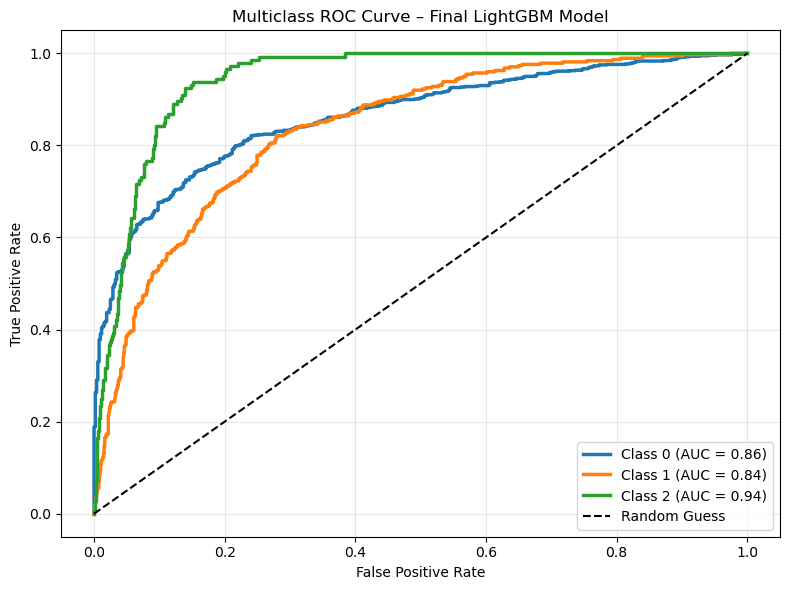

In [7]:
# Multiclass ROC Curve + AUC Visualization

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Convert labels to binary format
y_test_bin = label_binarize(y_test, classes=class_labels)

fpr = {}
tpr = {}
roc_auc = {}

for i, cls in enumerate(class_labels):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for i, cls in enumerate(class_labels):
    plt.plot(
        fpr[i],
        tpr[i],
        color=colors[i],
        linewidth=2.5,
        label=f"Class {cls} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0,1],[0,1],'k--',label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve – Final LightGBM Model")

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()

# Save figure in reports folder
plt.savefig(REPORTS_PATH / "multiclass_roc_curve.png", dpi=300)

plt.show()